#Module2

Task 1 — Load and profile the Titanic dataset

In [1]:
import seaborn as sns
import pandas as pd

# Load dataset only once
df = sns.load_dataset("titanic")

# Profile dataset
print("INFO")
df.info()

print("\nDESCRIBE")
print(df.describe())

print("\nSHAPE")
print(df.shape)

# Missing percentages
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

print("\nMISSING VALUES")
print(missing_table[missing_table["missing_count"] > 0])

# Save offline fallback
df.to_csv("titanic.csv", index=False)

print("\ntitanic.csv saved successfully")

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

DESCRIBE
         survived      pclass         age       sibsp       parc

Task 2 — Handle missing values

In [4]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

print(
    pd.DataFrame({
        "Missing Count": missing,
        "Missing %": missing_percent
    }).query("`Missing Count` > 0")
)

# Less than 5% → drop rows
if "embarked" in df.columns:
    embarked_missing = df["embarked"].isnull().mean() * 100

    if embarked_missing < 5:
        df = df.dropna(subset=["embarked"])


# 5%–30% → impute
if "age" in df.columns:
    age_missing = df["age"].isnull().mean() * 100

    if 5 <= age_missing <= 30:
        df["age"] = df["age"].fillna(df["age"].median())


# High missing column
if "deck" in df.columns:
    deck_missing = df["deck"].isnull().mean() * 100

    if deck_missing > 30:
        df["deck"] = df["deck"].cat.add_categories("missing")
        df["deck"] = df["deck"].fillna("missing")

      Missing Count  Missing %
deck            688  77.390326


In [5]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

print(
    pd.DataFrame({
        "Missing Count": missing,
        "Missing %": missing_percent
    }).query("`Missing Count` > 0")
)
# Less than 5% → drop rows
if "embarked" in df.columns:
    embarked_missing = df["embarked"].isnull().mean() * 100

    if embarked_missing < 5:
        df = df.dropna(subset=["embarked"])


# 5%–30% → impute
if "age" in df.columns:
    age_missing = df["age"].isnull().mean() * 100

    if 5 <= age_missing <= 30:
        df["age"] = df["age"].fillna(df["age"].median())


# High missing column
if "deck" in df.columns:
    deck_missing = df["deck"].isnull().mean() * 100

    if deck_missing > 30:
        df["deck"] = df["deck"].fillna("missing")

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


Task 3 — Univariate analysis

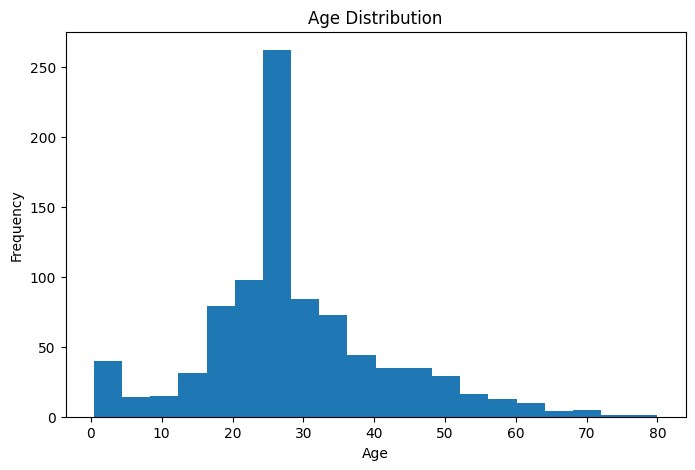

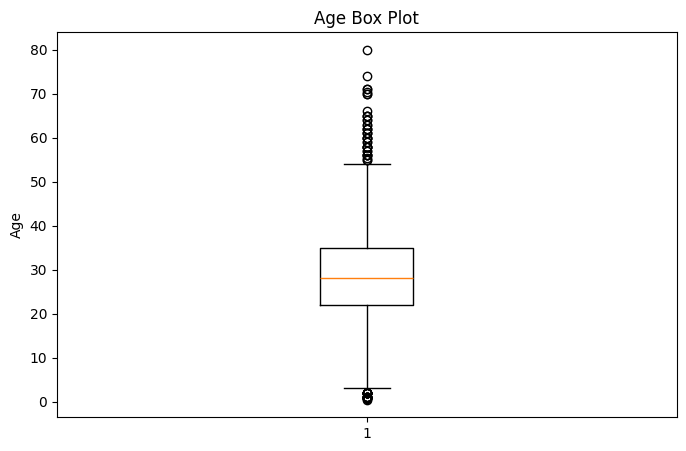

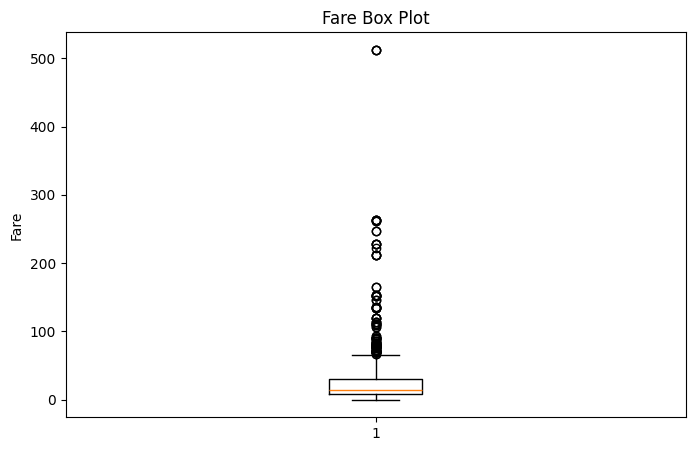

Age outliers: 65
Fare outliers: 114


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["age"].dropna(), bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()
plt.figure(figsize=(8, 5))
plt.boxplot(df["age"].dropna())
plt.ylabel("Age")
plt.title("Age Box Plot")
plt.show()
plt.figure(figsize=(8, 5))
plt.boxplot(df["fare"].dropna())
plt.ylabel("Fare")
plt.title("Fare Box Plot")
plt.show()
def count_outliers(column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return len(outliers), lower, upper


age_outliers, age_lower, age_upper = count_outliers("age")
fare_outliers, fare_lower, fare_upper = count_outliers("fare")

print("Age outliers:", age_outliers)
print("Fare outliers:", fare_outliers)

Task 4 — Bivariate analysis

In [9]:
male_survival = df.loc[
    df["sex"] == "male",
    "survived"
].mean()

female_survival = df.loc[
    df["sex"] == "female",
    "survived"
].mean()

print("Male survival rate:", male_survival)
print("Female survival rate:", female_survival)
for pclass in sorted(df["pclass"].unique()):

    rate = df.loc[
        df["pclass"] == pclass,
        "survived"
    ].mean()

    print(
        "Pclass",
        pclass,
        "survival rate:",
        rate
    )
    for sex in df["sex"].unique():

    for pclass in sorted(df["pclass"].unique()):

        rate = df.loc[
            (df["sex"] == sex) &
            (df["pclass"] == pclass),
            "survived"
        ].mean()

        print(
            sex,
            "Pclass",
            pclass,
            "survival rate:",
            rate
        )
        correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr = df[correlation_columns].corr()

print(corr)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Titanic Correlation Matrix")
plt.show()
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr = df[correlation_columns].corr()

print(corr)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Titanic Correlation Matrix")
plt.show()
corr_pairs = corr.abs().where(
    ~pd.DataFrame(
        True,
        index=corr.index,
        columns=corr.columns
    ).values
)

pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):

        feature1 = corr.columns[i]
        feature2 = corr.columns[j]

        value = corr.loc[feature1, feature2]

        pairs.append(
            (feature1, feature2, value, abs(value))
        )

pairs = sorted(
    pairs,
    key=lambda x: x[3],
    reverse=True
)

print("Two strongest correlations:")

for pair in pairs[:2]:
    print(pair)

IndentationError: expected an indented block after 'for' statement on line 26 (368603230.py, line 28)

Task 5 — Four multivariate charts

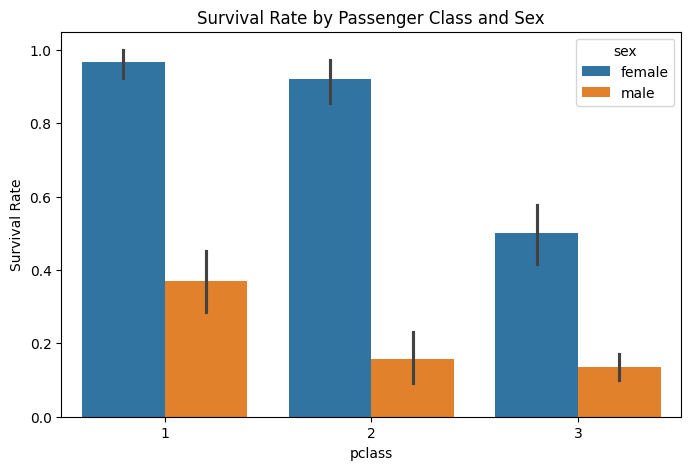

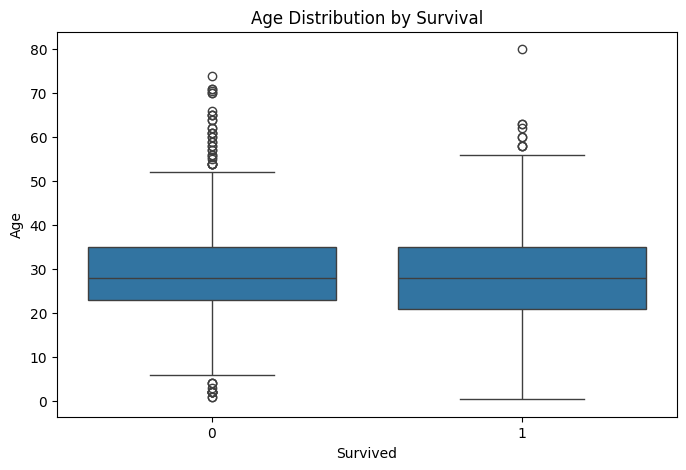

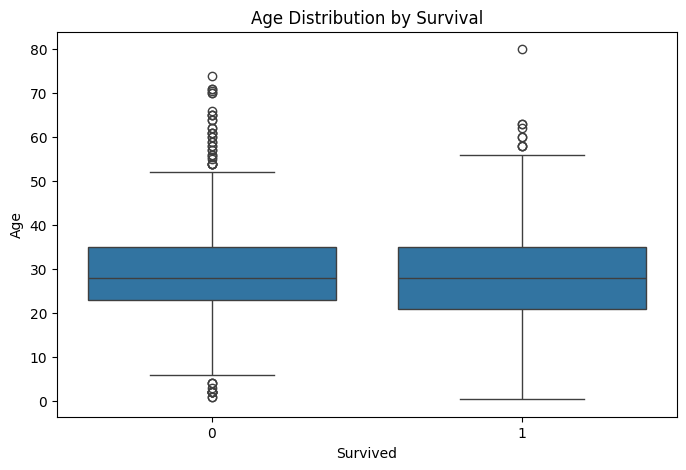

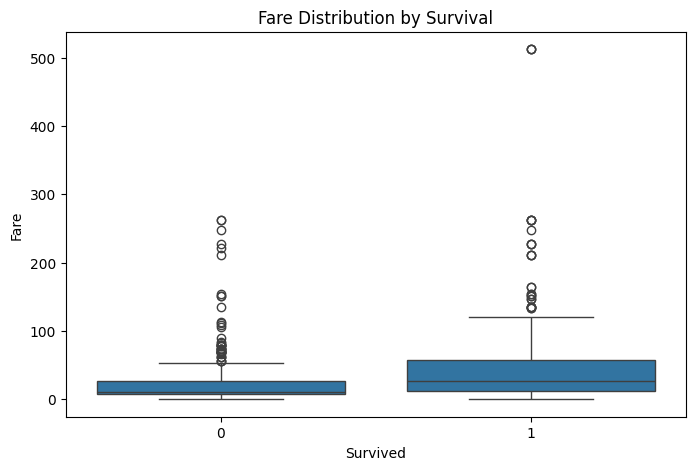

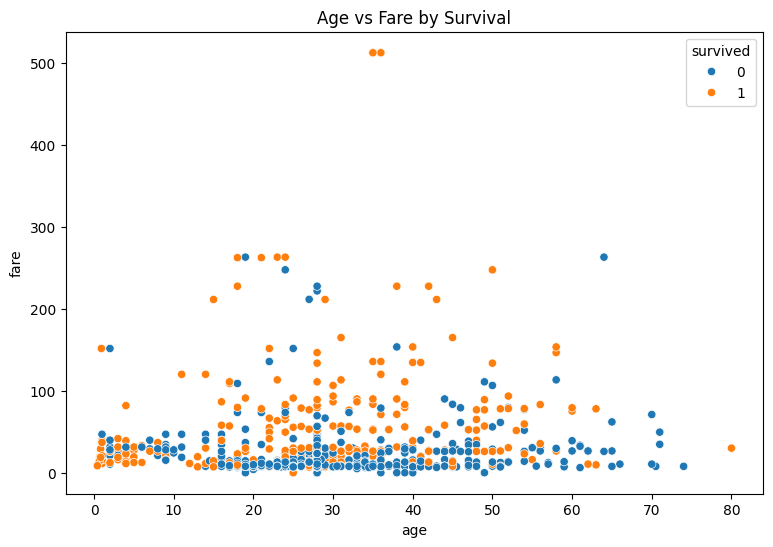

In [10]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Sex")
plt.ylabel("Survival Rate")
plt.show()
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare by Survival")
plt.show()

Task 6 — Standardization

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["age_scaled", "fare_scaled"]] = scaler.fit_transform(
    df[["age", "fare"]]
)

print("Before standardization:")
print(df[["age", "fare"]].agg(["mean", "std"]))

print("\nAfter standardization:")
print(df[["age_scaled", "fare_scaled"]].agg(["mean", "std"]))

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After standardization:
        age_scaled   fare_scaled
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


Part B — Predictive Modeling
Task 7 — Stratified train/test split

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining class balance:")
print(y_train.value_counts(normalize=True))

print("\nTesting class balance:")
print(y_test.value_counts(normalize=True))

Training rows: 711
Testing rows: 178

Training class balance:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing class balance:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


Task 8 — Preprocessing pipeline

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "age",
    "fare",
    "sibsp",
    "parch",
    "pclass"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

Task 9 — Train three classifiers

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

tree_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

forest_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fare', 'sibsp',
                                                   'parch', 'pclass']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('model', RandomForestClassifier(random_state=42))])

Task 10 — Evaluate all three models

In [15]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_probability)

    print("\n", name)
    print("Confusion Matrix:")
    print(cm)

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("AUC:", auc)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })


 Logistic Regression
Confusion Matrix:
[[97 13]
 [21 47]]
Accuracy: 0.8089887640449438
Precision: 0.7833333333333333
Recall: 0.6911764705882353
F1: 0.734375
AUC: 0.8609625668449199

 Decision Tree
Confusion Matrix:
[[98 12]
 [30 38]]
Accuracy: 0.7640449438202247
Precision: 0.76
Recall: 0.5588235294117647
F1: 0.6440677966101694
AUC: 0.8373663101604277

 Random Forest
Confusion Matrix:
[[96 14]
 [18 50]]
Accuracy: 0.8202247191011236
Precision: 0.78125
Recall: 0.7352941176470589
F1: 0.7575757575757576
AUC: 0.821457219251337


Task 11 — Imbalance comparison

In [16]:
print("Class balance:")
print(y.value_counts())

print("\nClass percentages:")
print(y.value_counts(normalize=True) * 100)
baseline_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_precision = precision_score(
    y_test,
    baseline_pred
)

baseline_recall = recall_score(
    y_test,
    baseline_pred
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred
)

Class balance:
survived
0    549
1    340
Name: count, dtype: int64

Class percentages:
survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


Task 12 — Random Forest GridSearchCV + OOB

In [17]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 100}


Task 13 — Regression

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

regression_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "survived"
]

X_reg = df[regression_features]
y_reg = df["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

regression_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        LinearRegression()
    )
])

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

y_reg_pred = regression_pipeline.predict(
    X_reg_test
)

mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

n = len(y_reg_test)
p = X_reg_test.shape[1]

adjusted_r2 = (
    1 -
    ((1 - r2) * (n - 1) / (n - p - 1))
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Adjusted R2:", adjusted_r2)

MAE: 20.669973608352628
RMSE: 42.44240378182529
R2: 0.3248142140256355
Adjusted R2: 0.30518672024731086


Task 14 — Final model comparison

In [19]:
classification_results = comparison_df.copy()

print(classification_results)
regression_results = pd.DataFrame({
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted_R2": [adjusted_r2]
})

print(regression_results)

NameError: name 'comparison_df' is not defined

Task 15 — Save and reload the complete pipeline

In [27]:
import joblib

# 1. Save the trained pipeline
joblib.dump(
    final_pipeline
    "best_titanic_pipeline.joblib"
)

print("Pipeline saved successfully!")

# 2. Load the saved pipeline
loaded_pipeline = joblib.load(
    "best_titanic_pipeline.joblib"
)

print("Pipeline loaded successfully!")

# 3. Take one sample from X_test
raw_sample = X_test.iloc[[0]]

# 4. Make prediction
prediction = loaded_pipeline.predict(raw_sample)

# 5. Display input
print("\nRaw input:")
print(raw_sample)

# 6. Display prediction
print("\nPrediction:")
print(prediction)

SyntaxError: invalid syntax (4031391535.py, line 6)